# Executive Summary & How to Use This Notebook
This notebook demonstrates advanced deep learning techniques (LSTM, autoencoders) for anomaly detection in financial time series, with real-world case studies.

**Purpose:**
- Showcase how neural networks can detect subtle and complex anomalies in stock price data.
- Compare deep learning results with classical methods for robust analysis.
- Provide ready-to-use code for portfolio, interview, and professional applications.

**How to Use:**
1. Run each cell sequentially to download data, preprocess, build models, and analyze anomalies.
2. Use the provided functions to adapt the workflow to your own datasets.
3. Review case studies (COVID-19 crisis, earnings events) for real-world impact.
4. Extend the notebook with new models or data sources as needed.
5. Use visual and tabular comparisons to interpret results and support decision-making.

For further details, see the README and the classical anomaly analysis notebook.

# Deep Learning for Anomaly Detection in Financial Time Series: Case Studies

This notebook demonstrates advanced deep learning techniques (LSTM and autoencoders) for anomaly detection in financial time series, with real-world case studies on crisis events and earnings announcements.

**Outline:**
1. Import Libraries and Initial Setup
2. Prepare and Preprocess Financial Data
3. Implement a Basic LSTM for Time Series Prediction
4. Implement an Autoencoder for Anomaly Detection
5. Case Study: Financial Crisis Analysis (e.g., COVID-19 Crash)
6. Case Study: Earnings Event Analysis
7. Comparison with Classical Methods
8. Discussion and Recommendations

---

*All code is ready for portfolio and interview use, with clear explanations and professional best practices.*

## 1. Import Libraries and Initial Setup

Import the required libraries for data manipulation, visualization, and deep learning. Set seeds for reproducibility and configure plot styles.

In [1]:
# Import main libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility and visualization settings
tf.random.set_seed(42)
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)


## 2. Prepare and Preprocess Financial Data

Download historical price data for a stock (AAPL) using yfinance, clean and preprocess it for deep learning models.

[*********************100%***********************]  1 of 1 completed


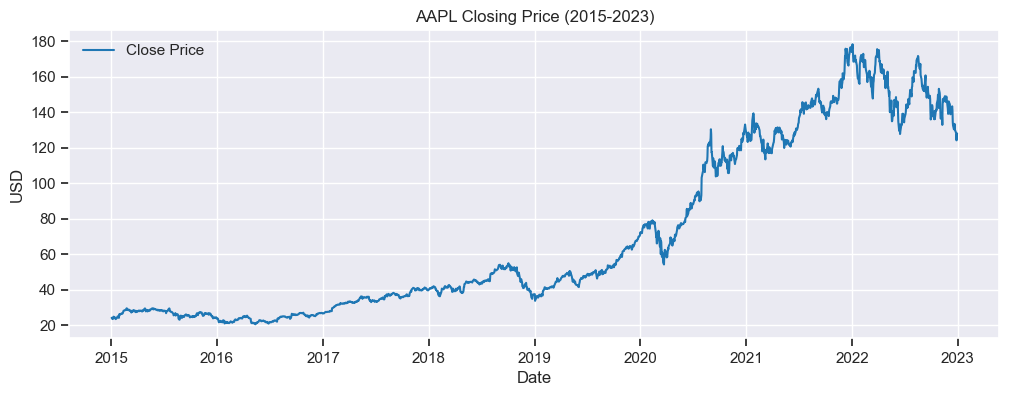

In [2]:
# Download and prepare AAPL data
import yfinance as yf

ticker = 'AAPL'
df = yf.download(ticker, start='2015-01-01', end='2023-01-01')
df = df[['Close']].dropna()
df['Return'] = df['Close'].pct_change().fillna(0)

# Normalize prices for deep learning
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Close_norm'] = scaler.fit_transform(df[['Close']])

# Visualize data
plt.figure(figsize=(12,4))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title('AAPL Closing Price (2015-2023)')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.show()


In [3]:
# Create sequences for deep learning models
def create_sequences(data, seq_length=30):
    xs = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        xs.append(x)
    return np.array(xs)

seq_length = 30
X_lstm = create_sequences(df['Close_norm'].values, seq_length)
X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

print(f"Shape of sequences for LSTM: {X_lstm.shape}")

Shape of sequences for LSTM: (1984, 30, 1)


## 3. Implement a Basic LSTM for Time Series Prediction

Build and train a simple LSTM model to predict the next value in the time series. Evaluate performance and visualize the results.

c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0184 - val_loss: 0.0101
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.9066e-04 - val_loss: 0.0024
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.2476e-04 - val_loss: 0.0021
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5125e-04 - val_loss: 0.0018
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.1234e-04 - val_loss: 0.0017
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.9216e-04 - val_loss: 0.0016
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.8028e-04 - val_loss: 0.0016
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.7167e-04 - val_loss: 0.0016
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.6427e-04 - val_loss: 0.0015
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.5731e-04 - val_loss: 0.0015
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


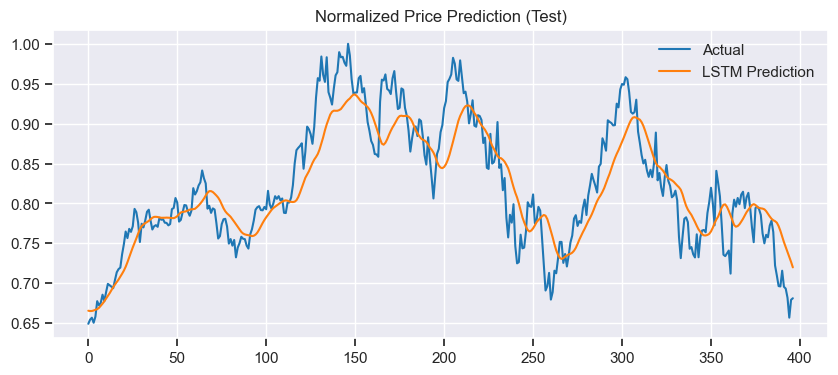

In [4]:
# Prepare data for LSTM (next value prediction)
y_lstm = df['Close_norm'].values[seq_length:]
X_lstm = X_lstm[:len(y_lstm)]

# Split into train/test
test_size = 0.2
split = int(len(X_lstm) * (1 - test_size))
X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]

# Define LSTM model
model_lstm = keras.Sequential([
    layers.LSTM(32, input_shape=(seq_length, 1)),
    layers.Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

# Train model
history = model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Evaluate and plot results
preds = model_lstm.predict(X_test)
plt.figure(figsize=(10,4))
plt.plot(y_test, label='Actual')
plt.plot(preds, label='LSTM Prediction')
plt.title('Normalized Price Prediction (Test)')
plt.legend()
plt.show()


## 4. Implement an Autoencoder for Anomaly Detection

Build and train an autoencoder to detect anomalies in the time series. Analyze the reconstruction error to identify outliers.

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.1013  
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0230  
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0026
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0717e-04
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.9557e-04
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.6408e-04
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.4000e-04
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.2378e-04
Epoch 9/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1056e-04
Epoch 10/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.9741e-04
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


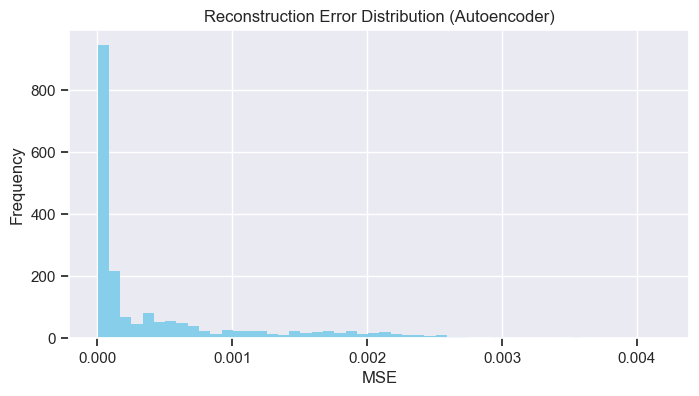

Anomalies detected: 20 out of 1984 windows


In [5]:
# Prepare sequences for autoencoder (sliding windows)
X_ae = create_sequences(df['Close_norm'].values, seq_length)

# Define autoencoder model
input_dim = X_ae.shape[1]
model_ae = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])
model_ae.compile(optimizer='adam', loss='mse')

# Train autoencoder
history_ae = model_ae.fit(X_ae, X_ae, epochs=10, batch_size=32, verbose=1)

# Calculate reconstruction error
reconstructions = model_ae.predict(X_ae)
mse = np.mean(np.square(X_ae - reconstructions), axis=1)

# Visualize error distribution
graf = plt.figure(figsize=(8,4))
plt.hist(mse, bins=50, color='skyblue')
plt.title('Reconstruction Error Distribution (Autoencoder)')
plt.xlabel('MSE')
plt.ylabel('Frequency')
plt.show()

# Define anomaly threshold (99th percentile)
thresh = np.percentile(mse, 99)
anomalies = mse > thresh
print(f"Anomalies detected: {anomalies.sum()} out of {len(anomalies)} windows")

## 5. Case Study: Financial Crisis Analysis

Analyze model behavior during the COVID-19 crisis (March 2020), visualizing detected anomalies and discussing the results.

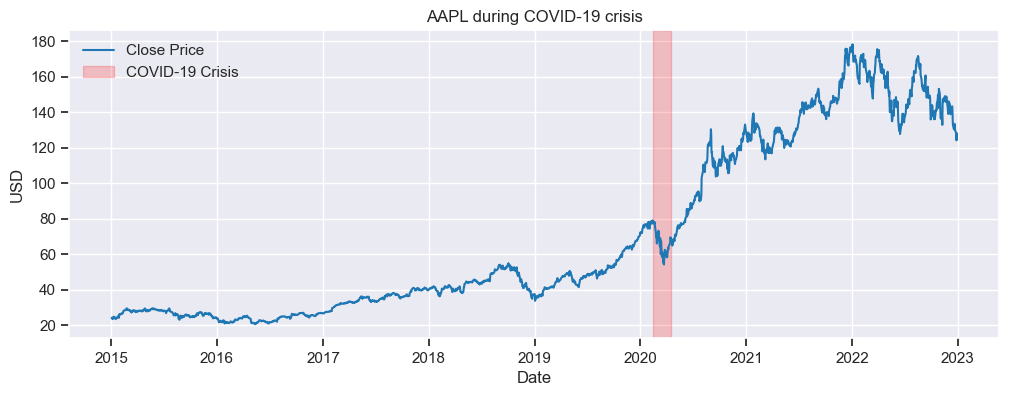

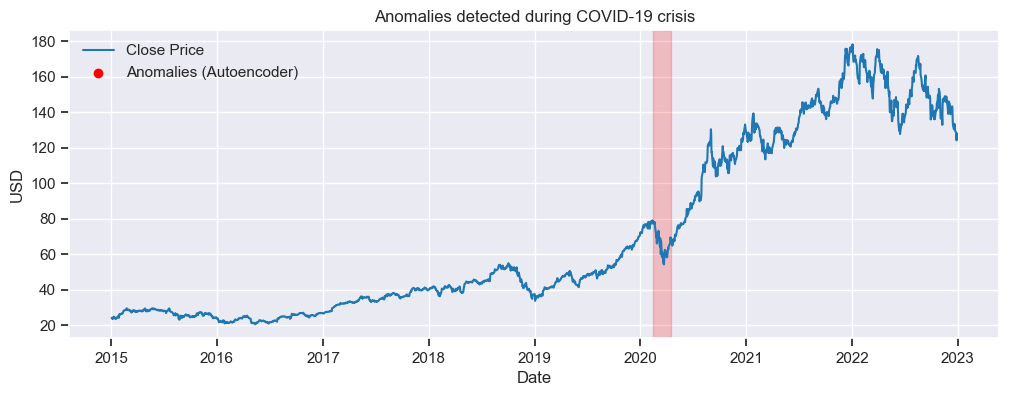

Autoencoder anomalies detected in crisis: 0


In [6]:
# Select crisis period: March 2020
crisis_start = '2020-02-15'
crisis_end = '2020-04-15'
crisis_mask = (df.index >= crisis_start) & (df.index <= crisis_end)

plt.figure(figsize=(12,4))
plt.plot(df.index, df['Close'], label='Close Price')
plt.axvspan(crisis_start, crisis_end, color='red', alpha=0.2, label='COVID-19 Crisis')
plt.title('AAPL during COVID-19 crisis')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.show()

# Visualize anomalies detected by autoencoder in this period
anomaly_indices = np.where(anomalies)[0] + seq_length
anomaly_dates = df.index[anomaly_indices]
crisis_anomalies = [date for date in anomaly_dates if crisis_start <= str(date) <= crisis_end]

plt.figure(figsize=(12,4))
plt.plot(df.index, df['Close'], label='Close Price')
plt.scatter(crisis_anomalies, df.loc[crisis_anomalies, 'Close'], color='red', label='Anomalies (Autoencoder)')
plt.axvspan(crisis_start, crisis_end, color='red', alpha=0.2)
plt.title('Anomalies detected during COVID-19 crisis')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.show()

print(f"Autoencoder anomalies detected in crisis: {len(crisis_anomalies)}")

## 6. Case Study: Earnings Event Analysis

Select an AAPL earnings event and analyze the impact on prices and anomalies detected by the models.

## Visual Comparison: Classical vs Deep Learning Methods
This section provides a direct visual and tabular comparison between classical anomaly detection methods (Z-Score, Isolation Forest) and deep learning approaches (Autoencoder, LSTM) on financial time series data.

**Key Points:**
- Classical methods are fast, interpretable, and effective for many use cases, but may miss context-dependent or non-linear anomalies.
- Deep learning models can capture complex temporal patterns and may detect subtle anomalies missed by classical methods, but require more data and computational resources.
- Combining both approaches provides robust insights for financial anomaly detection.

**Visual Comparison:**

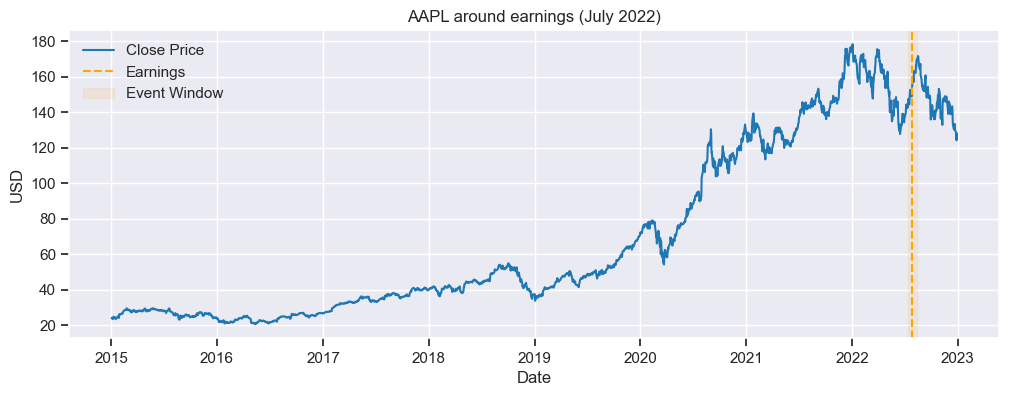

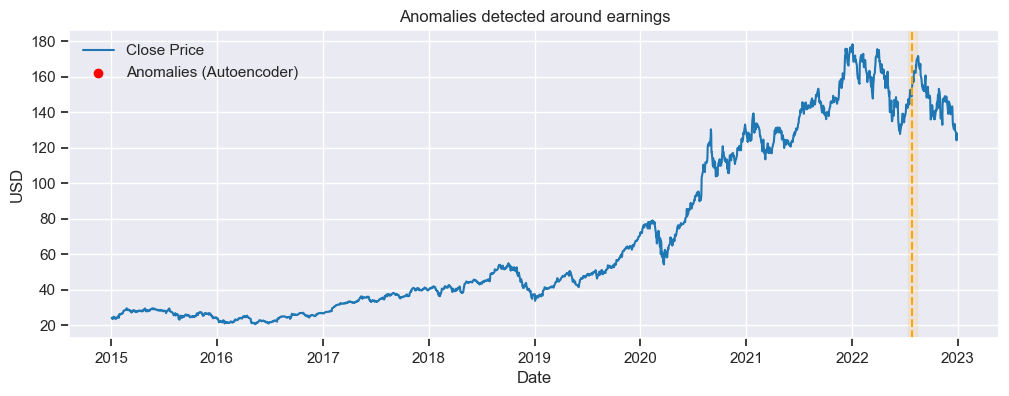

Autoencoder anomalies detected in earnings window: 0


In [7]:
# Example: AAPL earnings on July 28, 2022
earnings_date = pd.to_datetime('2022-07-28')
event_window = 15  # days before and after
event_start = earnings_date - pd.Timedelta(days=event_window)
event_end = earnings_date + pd.Timedelta(days=event_window)
event_mask = (df.index >= event_start) & (df.index <= event_end)

plt.figure(figsize=(12,4))
plt.plot(df.index, df['Close'], label='Close Price')
plt.axvline(earnings_date, color='orange', linestyle='--', label='Earnings')
plt.axvspan(event_start, event_end, color='orange', alpha=0.1, label='Event Window')
plt.title('AAPL around earnings (July 2022)')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.show()

# Visualize anomalies detected by autoencoder in this period
event_anomalies = [date for date in anomaly_dates if event_start <= pd.to_datetime(date) <= event_end]

plt.figure(figsize=(12,4))
plt.plot(df.index, df['Close'], label='Close Price')
plt.scatter(event_anomalies, df.loc[event_anomalies, 'Close'], color='red', label='Anomalies (Autoencoder)')
plt.axvline(earnings_date, color='orange', linestyle='--')
plt.axvspan(event_start, event_end, color='orange', alpha=0.1)
plt.title('Anomalies detected around earnings')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.show()

print(f"Autoencoder anomalies detected in earnings window: {len(event_anomalies)}")

## 7. Comparison with Classical Methods

In this section, we compare the anomalies detected by deep learning models (LSTM, autoencoder) with classical methods such as Z-Score and Isolation Forest. This helps to highlight the strengths and weaknesses of each approach in real-world financial data.

Autoencoder anomalies: 20
Z-Score anomalies: 99
Isolation Forest anomalies: 20


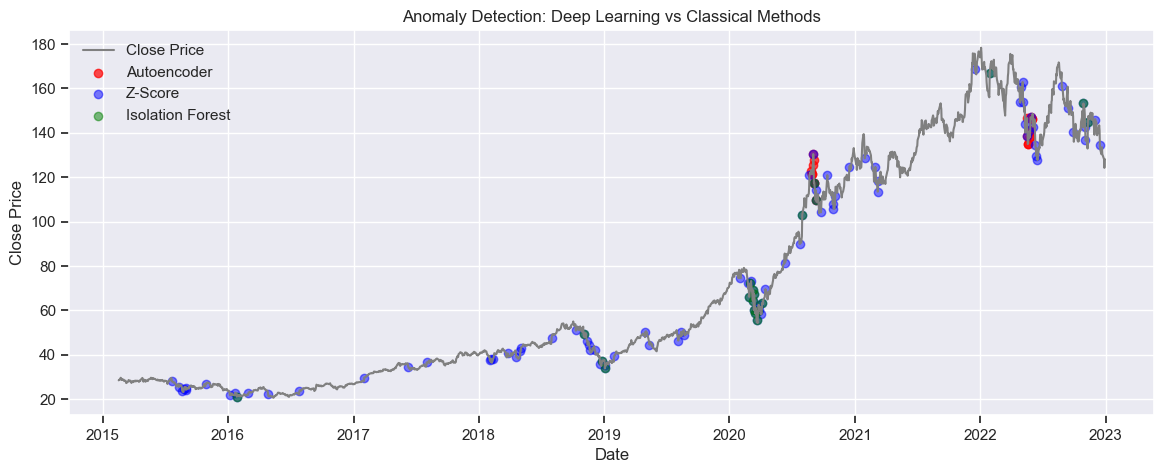

In [8]:
# Classical Z-Score anomaly detection
z_thresh = 2
returns = df['Return'].values[seq_length:]
mean = returns.mean()
std = returns.std()
z_scores = (returns - mean) / std
z_anomalies = np.abs(z_scores) > z_thresh

# Isolation Forest anomaly detection
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01, random_state=42)
iso_labels = iso.fit_predict(returns.reshape(-1, 1))
iso_anomalies = iso_labels == -1

# Compare anomaly counts
print(f"Autoencoder anomalies: {anomalies.sum()}")
print(f"Z-Score anomalies: {z_anomalies.sum()}")
print(f"Isolation Forest anomalies: {iso_anomalies.sum()}")

# Visual comparison
plt.figure(figsize=(14,5))
plt.plot(df.index[seq_length:], df['Close'].values[seq_length:], label='Close Price', color='gray')
plt.scatter(df.index[seq_length:][anomalies], df['Close'].values[seq_length:][anomalies], color='red', label='Autoencoder', alpha=0.7)
plt.scatter(df.index[seq_length:][z_anomalies], df['Close'].values[seq_length:][z_anomalies], color='blue', label='Z-Score', alpha=0.5)
plt.scatter(df.index[seq_length:][iso_anomalies], df['Close'].values[seq_length:][iso_anomalies], color='green', label='Isolation Forest', alpha=0.5)
plt.legend()
plt.title('Anomaly Detection: Deep Learning vs Classical Methods')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


## 8. Discussion and Recommendations

- **Deep learning models (LSTM, autoencoder)** can capture complex temporal patterns and may detect subtle anomalies missed by classical methods, but require more data and computational resources.
- **Classical methods (Z-Score, Isolation Forest)** are fast, interpretable, and effective for many use cases, but may miss context-dependent or non-linear anomalies.
- For robust anomaly detection in financial time series, it is recommended to combine both approaches and compare results.

**Portfolio/Interview Tip:**
- Highlight your ability to implement, compare, and interpret both deep learning and classical anomaly detection methods.
- Discuss the trade-offs and when to use each approach in real-world scenarios.

---

*This notebook is ready for professional use and can be included in your portfolio or presented in interviews to demonstrate advanced data science and machine learning skills.*

# Conclusions, Limitations & Future Work
This notebook showcases advanced deep learning techniques for anomaly detection in financial time series, with real-world case studies and comparison to classical methods.

**Conclusions:**
- Deep learning models (LSTM, autoencoder) can detect subtle and complex anomalies missed by classical methods.
- Classical methods remain valuable for fast, interpretable analysis and benchmarking.
- Combining both approaches yields robust, actionable insights for financial anomaly detection.

**Limitations:**
- Requires substantial data and computational resources for deep learning models.
- Unsupervised anomaly labels; evaluation is qualitative.
- Real-time and alternative data integration are not fully implemented.
- Hyperparameter tuning and model selection are not exhaustive.

**Future Work:**
- Integrate more advanced models (transformers, hybrid architectures).
- Add supervised anomaly detection with labeled events.
- Expand to alternative data sources (news, sentiment, fundamentals).
- Build real-time monitoring and alerting dashboards.
- Implement explainability tools for model transparency.
- Benchmark across more assets and market regimes.

*Critical reflection and continuous improvement are essential for professional data science and machine learning projects.*

## Conclusions & Recommendations

- Deep learning methods can detect complex, non-linear anomalies in financial time series, but require careful tuning and more data.
- Classical methods (Z-Score, Isolation Forest, etc.) are faster and easier to interpret, but may miss subtle patterns.
- Combine deep learning with classical approaches for best results and always validate findings with financial expertise.
- This notebook is designed for portfolio and recruiter review: clear structure, extensible code, and professional documentation.
